In [ ]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)
# https://drive.google.com/file/d/19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8/view?usp=sharing
!gdown --id 19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8
From (redirected): https://drive.google.com/uc?id=19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8&confirm=t&uuid=523223d9-afb8-48c1-9a21-e2c5914b0a5d
To: /content/data_GOES_tp.zip
100% 755M/755M [00:20<00:00, 36.4MB/s]


In [ ]:
# --
#!unzip -qq data_GOES_tp.zip

replace drive-download-20260330T121459Z-1-001/OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace drive-download-20260330T121459Z-1-001/OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace drive-download-20260330T121459Z-1-001/OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace drive-download-20260330T121459Z-1-001/OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace drive-download-20260330T121459Z-1-001/OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace drive-download-20260330T121

In [ ]:
#--
import xarray as xr

! pip install rioxarray
import rioxarray

import numpy as np
from matplotlib import pyplot as plt

import rasterio as rt
from rasterio.plot import show
from rasterio.crs import CRS
from rasterio.enums import Resampling

import os

In [ ]:
# Define folder path
directory_path = '/content/drive-download-20260330T121459Z-1-001/'

# List all files in the directory
all_files = os.listdir(directory_path)

# Sort the paths
all_filles_sorted = []

for b in range(len(all_files)):
  for p in all_files:
    if int(p[20]) == (b+1):
      all_filles_sorted.append(p)

In [ ]:
# Visualize and check files path sorting
all_filles_sorted

['OR_ABI-L1b-RadF-M6C01_G16_s20212301400207_e20212301409515_c20212301409562.nc',
 'OR_ABI-L1b-RadF-M6C02_G16_s20212301400207_e20212301409515_c20212301409550.nc',
 'OR_ABI-L1b-RadF-M6C03_G16_s20212301400207_e20212301409515_c20212301409564.nc',
 'OR_ABI-L1b-RadF-M6C04_G16_s20212301400207_e20212301409515_c20212301409546.nc',
 'OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc',
 'OR_ABI-L1b-RadF-M6C06_G16_s20212301400207_e20212301409520_c20212301409553.nc',
 'OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc']

In [ ]:
# Select bounding box limits
xmin, xmax = -0.025, 0.11
ymin, ymax = 0.04, -0.15

## Bands 1-6 to reflectance and plot RGB

In [ ]:
# Resample bands
def resampling_xarray(band_org, band_res):

    if band_org.rio.shape != band_res.rio.shape:
        return band_res.rio.reproject_match(
            band_org,
            resampling=Resampling.bilinear
        )
    else:
        return band_res

In [ ]:
# Extract radiance data, compute reflectance and store them in a nxmxt array

listBands_refls = []
band_org = xr.open_dataset(directory_path+all_filles_sorted[0], decode_coords="all") # Set band 1 as the reference
band_org = band_org.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))

for b in range(6): # bands 1 to 6
  print(all_filles_sorted[b])
  goes_band = xr.open_dataset(directory_path+all_filles_sorted[b], decode_coords="all")
  goes_band = goes_band.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))
  rad_to_ref = goes_band.Rad*goes_band.kappa0
  # Explicitly set the CRS for rad_to_ref
  rad_to_ref = rad_to_ref.rio.write_crs(goes_band.Rad.rio.crs)
  #rad_to_ref.to_netcdf(f'band{b}_res.nc')
  print(rad_to_ref.shape)
  band_res = resampling_xarray(band_org, rad_to_ref)
  print(band_res.shape)
  listBands_refls.append(band_res.values)

arrayBands_refls = np.array(listBands_refls)

OR_ABI-L1b-RadF-M6C01_G16_s20212301400207_e20212301409515_c20212301409562.nc
(6786, 4822)
(6786, 4822)
OR_ABI-L1b-RadF-M6C02_G16_s20212301400207_e20212301409515_c20212301409550.nc
(13571, 9643)
(6786, 4822)
OR_ABI-L1b-RadF-M6C03_G16_s20212301400207_e20212301409515_c20212301409564.nc
(6786, 4822)
(6786, 4822)
OR_ABI-L1b-RadF-M6C04_G16_s20212301400207_e20212301409515_c20212301409546.nc
(3393, 2410)
(6786, 4822)
OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc
(6786, 4822)
(6786, 4822)
OR_ABI-L1b-RadF-M6C06_G16_s20212301400207_e20212301409520_c20212301409553.nc
(3393, 2410)
(6786, 4822)


In [ ]:
# Store reflectance bands in a xarray dataset
bands1to6_reflc = xr.Dataset(coords=band_org.coords, attrs=band_org.attrs)

for b in range(len(listBands_refls)):
  bands1to6_reflc[f'band{b+1}_refl'] =  xr.DataArray(arrayBands_refls[b], coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])
  bands1to6_reflc[f'band{b+1}_refl'] = bands1to6_reflc[f'band{b+1}_refl'].rio.write_crs(band_org.rio.crs) # Set band 1 crs as reference

# OPTIONAL: visualize dataset
#bands1to6_reflc

# Compute and store pseudo-green band
bands1to6_reflc[f'bandSG_refl'] =  xr.DataArray(0.45*arrayBands_refls[1] + 0.1*arrayBands_refls[2] + 0.45*arrayBands_refls[0],
                                                coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])
bands1to6_reflc[f'bandSG_refl'] = bands1to6_reflc[f'bandSG_refl'].rio.write_crs(band_org.rio.crs) # Set band 1 crs as reference

# OPTIONAL: visualize dataset
#bands1to6_reflc

In [ ]:
# Functions to equalize and plot bands composition
def nequalize(array, p=5, nodata=0):
    if len(array.shape) == 2:
        valid = array[np.isfinite(array) & (array != nodata)]
        if valid.size == 0:
            return np.full_like(array, np.nan, dtype=float)
        vmin = np.percentile(valid, p)
        vmax = np.percentile(valid, 100 - p)
        if vmax == vmin:
            return np.zeros_like(array, dtype=float)
        eq_array = (array - vmin) / (vmax - vmin)
        eq_array[eq_array > 1] = 1
        eq_array[eq_array < 0] = 0

        return eq_array

    elif len(array.shape) == 3:
        eq_array = np.empty_like(array, dtype=float)
        for i in range(array.shape[0]):
            eq_array[i] = nequalize(array[i], p=p, nodata=nodata)

        return eq_array

# def plot_rgb(array, band_list , p = 0, nodata = None, figsize = (12,6), title = None):
def plot_rgb(array, p = 0, nodata = None, figsize = (12,6), title = None, ticks_on = False):
    '''
    Esta función toma como parámetros de entrada la matriz a ser ploteada,
    una lista de índices correspondientes a las bandas que queremos usar,
    en el orden que deben estar (ej: [1,2,3]), y un parámetro p que es opcional
    que es el percentil de equalización.

    Por defecto tambien asigna un tamaño de figura en (12,6), que también puede ser modificado.

    Devuelve solamente un ploteo, no modifica el arreglo original.
    Nota: array debe ser una matriz con estas dimensiones de entrada: [bandas, filas, columnas]
    '''
    #if not title:
    #    title = f'Combinación {band_list} \n (percentil {p}%)'

    img = nequalize(array, p=p, nodata=nodata)
    plt.figure(figsize = figsize, )
    plt.title(title , size = 20)
    show(img)
    plt.show()

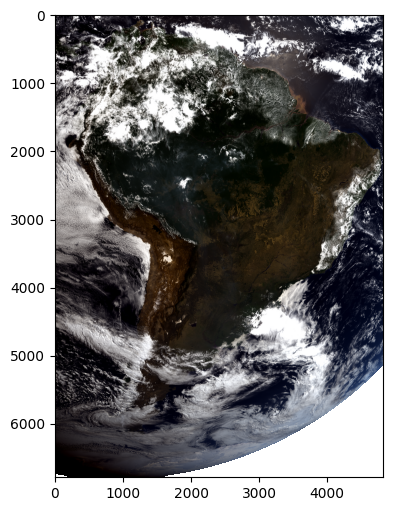

In [ ]:
# Extract bands data and plot
band_r = bands1to6_reflc.band2_refl.values
band_g = bands1to6_reflc.bandSG_refl.values
band_b = bands1to6_reflc.band1_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

## Plot bands composition
#plot_rgb(array, p = 5)

## Band 7 to bright temperature

In [ ]:
print(all_filles_sorted[6])
goes_band7 = xr.open_dataset(directory_path+all_filles_sorted[6], decode_coords="all")

OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc


In [ ]:
# Bands algebra computing
arg_log = (goes_band7.planck_fk1/goes_band7.Rad)+1
num_bt = (goes_band7.planck_fk2/np.log(arg_log))-goes_band7.planck_bc1
den_bt = goes_band7.planck_bc2

band7_toBT = num_bt/den_bt

# Resample band 7
band7_toBT = band7_toBT.rio.write_crs(goes_band.Rad.rio.crs)
print(band7_toBT.shape)
band7_toBT_res = resampling_xarray(band_org, band7_toBT) # resample to band 1 (band_org)
print(band7_toBT_res.shape)

/usr/local/lib/python3.12/dist-packages/xarray/computation/apply_ufunc.py:820: RuntimeWarning: invalid value encountered in log
  result_data = func(*input_data)


(5424, 5424)
(6786, 4822)


In [ ]:
# --
bands_1to7 = bands1to6_reflc.copy()

bands_1to7['band7_BT'] = xr.DataArray(band7_toBT_res.values, coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])
bands_1to7['band7_BT'] = bands_1to7['band7_BT'].rio.write_crs(band_org.rio.crs) # Set band 1 crs as reference

# OPTIONAL: visualize dataset
#bands_1to7

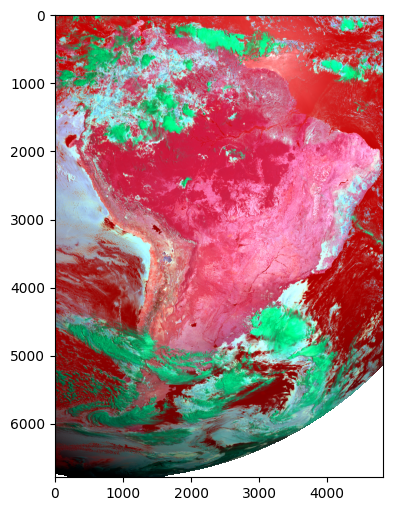

In [ ]:
# Extract bands data and plot
band_r = bands_1to7.band7_BT.values
band_g = bands_1to7.band6_refl.values
band_b = bands_1to7.band5_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

## Plot bands composition
#plot_rgb(array, p = 3)

## Map fire event (Córdoba)

In [ ]:
# Reproject to EPSG 4326
## NOTE: GOES data must be first converted from scan angles to meters

h = bands_1to7.band7_BT.rio.crs.to_dict()["h"] # Get satellite height (h) value

bands1to7_meters = bands_1to7.assign_coords(
    x = bands_1to7.x * h,
    y = bands_1to7.y * h
)

#bands1to7_latlon = bands1to7_latlon.rio.reproject("EPSG:4326")

In [ ]:
# Select data according to a bounding box
xmin, xmax, ymax, ymin = 889647.1495, 1041986.1762,-3316993.1354,-3158802.4175
bands1to7_fire = bands1to7_meters.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))

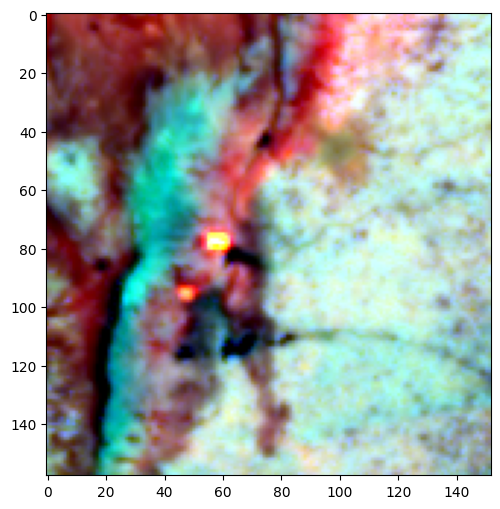

In [ ]:
# Extract bands data and plot
band_r = bands1to7_fire.band7_BT.values
band_g = bands1to7_fire.band6_refl.values
band_b = bands1to7_fire.band5_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

plot_rgb(array, p = 3)

In [ ]:
# Reproject and save data as netcdf
bands1to7_fire_latlon = bands1to7_fire.rio.reproject("EPSG:4326")
bands1to7_fire_latlon.to_netcdf('fire_event_goes.nc')